# Hull Moving Average — does the lag-free line really cut false signals?
### Alan Hull's near-zero-lag moving average, turned into a timing rule and tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cuts false signals%3F: Busted](https://img.shields.io/badge/Cuts_false_signals%3F-Busted-8b949e?style=flat-square)

Here's a recipe you'll meet on almost every charting platform: plot the **Hull Moving Average** instead of a plain moving average. Because it's built to lag far less, the story goes, it turns *earlier* and gives you **fewer false signals** — fewer of those annoying flip-flops ('whipsaws') that chop up a simple moving-average rule. Sounds great. Does it actually beat just buying and holding — or even beat a plain SMA?

> This is the plain-language layer. Want the *t*-stats, the permutation placebo, and the cost sweeps? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hull_moving_average import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-06-13"

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    b = data.load_real(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does HMA timing beat buy-and-hold? | **No.** It trails by **-4.35 bps/day** (*t* = -5.31) — net Sharpe **0.089** vs **0.646** for just holding. |
| Fewer false signals than a plain SMA? | **No — the opposite.** HMA fires **32.5 switches/yr** vs the SMA's **17.4** — nearly *double* the whipsaws. |
| Does it at least beat the simpler SMA rule? | **No.** SMA net Sharpe 0.465 > HMA 0.089. The fancy indicator loses to the plain one. |
| Is the timing real or random? | **Worse than random.** A shuffle of its own calls beats the real ones every single time (*p* = 1). |

> The HMA genuinely lags less — that part is true. But on noisy daily stock data, reacting faster just means reacting to more noise. Lower lag bought *more* false signals, not fewer.

## 1 · The claim

> *"The Hull Moving Average hugs price with almost no lag. A simple moving average is always late — by the time it turns, half the move is gone, and it whipsaws you in and out during chop. The HMA fixes both: it turns earlier AND gives fewer false signals. Trade in the direction the HMA is pointing and you'll catch trends a plain MA misses."*

Alan Hull built the HMA in 2005 by stacking weighted moving averages: `HMA(n) = WMA(2·WMA(n/2) − WMA(n), √n)`. The middle term over-weights recent price to cancel lag; the outer term re-smooths. As a *line on a chart*, it really does track turns faster than an SMA. We test whether that faster line makes *better trades*.

## 2 · So what?

Lag is the original sin of moving averages — every trader who has been stopped out by a late signal wants a faster line. If the HMA delivers earlier turns *and* fewer false signals, it would be a strict upgrade you could drop into any moving-average strategy. Millions of retail charts default to it. But if 'faster' just means 'noisier', then switching to the HMA makes your trading *worse* while feeling more responsive — the most seductive kind of mistake.

## 3 · How would we know?

The honest test isn't 'does the HMA rule make money' — in a 33-year bull market almost any mostly-long rule does. The honest tests are:

1. **Race the timing against just holding.** Go long when the HMA is rising, sit in cash when it's falling. Then subtract a buy-and-hold of the same asset. If the HMA's *timing* adds anything, that difference (the 'active spread') should be positive.
2. **Count the whipsaws.** Compare the HMA rule's number of in/out switches per year against a plain SMA rule. 'Fewer false signals' is a countable claim.
3. **Beat the simpler benchmark.** If the HMA doesn't beat a plain SMA(50) rule, the extra machinery earned nothing.

We enter one day after each signal (no peeking), charge realistic costs, and run it on SPY plus four other liquid tapes over ~33 years.

## 4 · The teardown — what actually happens

**First: the HMA timing rule vs the benchmarks vs just holding.** Net of 2 bps cost, long-when-rising on SPY.

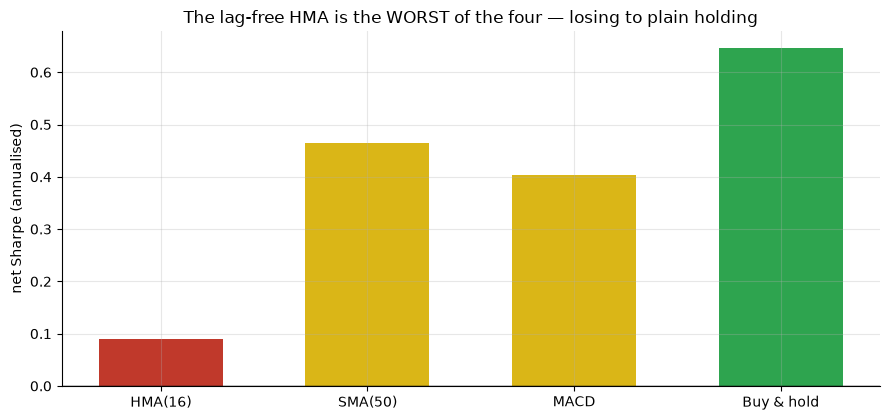

HMA 0.089 | SMA 0.465 | MACD 0.404 | hold 0.646


In [2]:
if HAVE_REAL:
    res = st.run_experiment(tape('SPY'), hma_period=16, sma_period=50, cost_bps=2.0)
    sh = {k: res[k]['sharpe_net'] for k in ('HMA','SMA','MACD')}
    sh['B&H'] = res['HMA']['bh_sharpe']
else:
    sh = dict(HMA=0.089, SMA=0.465, MACD=0.404)
    sh['B&H'] = 0.646
labels = ['HMA(16)','SMA(50)','MACD','Buy & hold']
vals = [sh['HMA'], sh['SMA'], sh['MACD'], sh['B&H']]
col = [RED, AMBER, AMBER, GREEN]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(labels, vals, color=col, width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (annualised)')
ax.set_title('The lag-free HMA is the WORST of the four — losing to plain holding')
plt.tight_layout(); plt.show()
print(f"HMA {sh['HMA']:.3f} | SMA {sh['SMA']:.3f} | MACD {sh['MACD']:.3f} | hold {sh['B&H']:.3f}")

Buy-and-hold (Sharpe **0.646**) beats every timing rule, and the supposedly superior HMA (**0.089**) is the *worst* of them — below even the plain SMA (**0.465**). Sitting in cash through chunks of a bull market is the price, and the HMA's earlier signals never pay it back.

**Now the headline claim itself: fewer false signals?** Count the in/out switches each rule asks for per year.

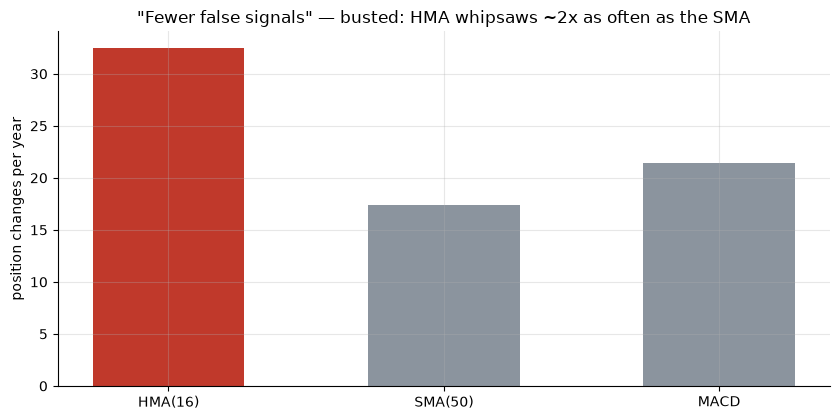

HMA 32.5/yr  vs  SMA 17.4/yr  ->  1.9x more switches


In [3]:
if HAVE_REAL:
    sw = {k: res[k]['switches_per_yr'] for k in ('HMA','SMA','MACD')}
else:
    sw = dict(HMA=32.5, SMA=17.4, MACD=21.4)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['HMA(16)','SMA(50)','MACD'], [sw['HMA'], sw['SMA'], sw['MACD']],
       color=[RED, GREY, GREY], width=.55)
ax.set_ylabel('position changes per year')
ax.set_title('\"Fewer false signals\" — busted: HMA whipsaws ~2x as often as the SMA')
plt.tight_layout(); plt.show()
print(f"HMA {sw['HMA']:.1f}/yr  vs  SMA {sw['SMA']:.1f}/yr  ->  {sw['HMA']/sw['SMA']:.1f}x more switches")

The HMA fires **32.5 switches/yr** against the SMA's **17.4** — nearly double. The whole reason to use the HMA was *fewer* false signals; it delivers *more*. Lower lag means it reacts to every wiggle, and most daily wiggles are noise.

**Is the timing even real?** We take the HMA's actual position calls and *shuffle* them in time — same number of trades, same long bias, but the calls now land on random days. If the real timing is skillful, it should beat its own shuffles.

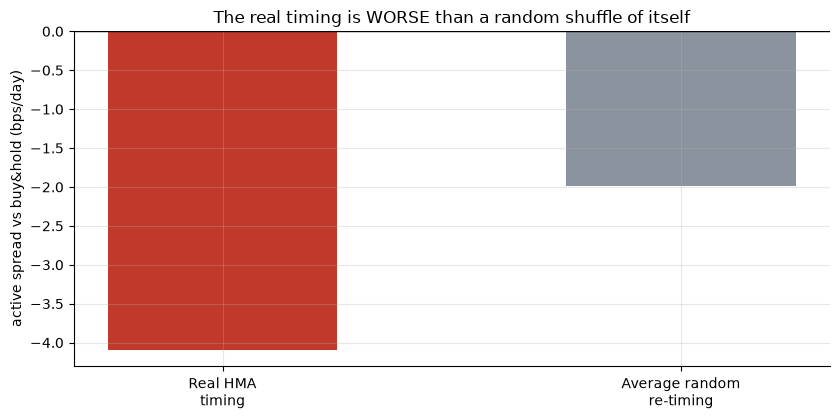

real -4.10 bps/day | random -1.99 bps/day | p = 1.000


In [4]:
if HAVE_REAL:
    p = res['HMA_permutation']
    obs, plac, pv = p['observed_spread_bps'], p['placebo_mean_bps'], p['p_value']
else:
    obs, plac, pv = -4.1, -1.99, 1.0
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Real HMA\ntiming', 'Average random\nre-timing'], [obs, plac],
       color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active spread vs buy&hold (bps/day)')
ax.set_title('The real timing is WORSE than a random shuffle of itself')
plt.tight_layout(); plt.show()
print(f'real {obs:+.2f} bps/day | random {plac:+.2f} bps/day | p = {pv:.3f}')

The real HMA timing (**-4.1 bps/day**) is *worse* than the average random re-timing (**-1.99 bps/day**), and **100%** of shuffles beat it. The HMA's calls don't just fail to help — they actively point the wrong way more often than chance.

## 5 · The verdict

- **Signal — None.** Active spread vs holding **-4.35 bps/day**, *t* = **-5.31** — significantly negative. Permutation *p* = 1.
- **Tradability — Mirage.** Net Sharpe **0.089** vs buy-and-hold **0.646**; loses even gross, and no cost level rescues it.
- **Cuts false signals? — Busted.** **32.5** switches/yr vs the SMA's **17.4** — nearly twice the whipsaws, and a lower Sharpe than that SMA.

## 6 · Could you actually trade it?

No. The gross timing already loses to holding; costs only widen the gap. There's no break-even cost because the line starts below zero:

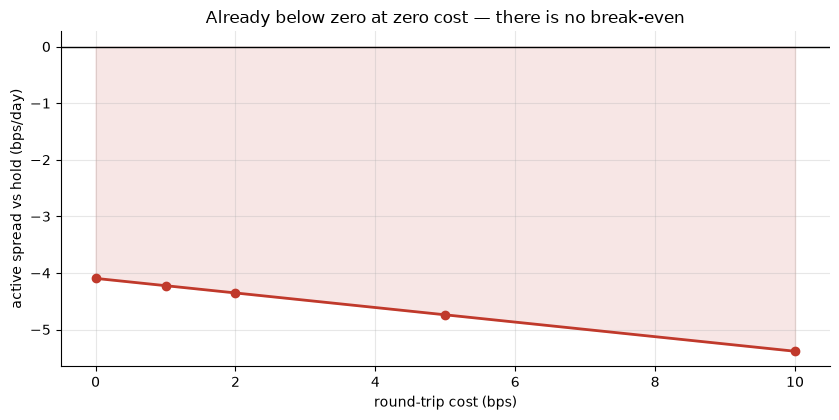

The gross spread is negative; costs are not the issue, the timing is.


In [5]:
if HAVE_REAL:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), cost_bps=c)['HMA']['mean_spread_bps'] for c in costs]
else:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]; spr = [-4.1, -4.23, -4.35, -4.74, -5.38]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, spr, 0, color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('active spread vs hold (bps/day)')
ax.set_title('Already below zero at zero cost — there is no break-even')
plt.tight_layout(); plt.show()
print('The gross spread is negative; costs are not the issue, the timing is.')

## 7 · Going further

- **The positive control.** The companion notebook plants a real trend in a synthetic tape — and the *same* HMA engine catches it cleanly (*t* up to +14). The harness works; the daily stock market just doesn't trend at the scale the HMA reacts to.
- **Slower windows / weekly bars.** A longer HMA, or weekly data, would whipsaw less — worth a fork to see if it merely matches the SMA or finally beats holding.
- **Other indicators, same fate.** See [Study 178 (CCI)](../../178-cci/) and [Study 104 (Bollinger)](../../104-bollinger-reversion/) — textbook indicators raced fairly tend to land here.

*Think the HMA earns its keep on a different timeframe or asset? Fork this, change the instrument or window, and show an active spread that clears HAC *t* = 2 against buy-and-hold. That's the bar.*